In [1]:
# Import libraries for comparing baseline vs. tree-based models
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

In [2]:
# Load the train/test sets built in Week 3 
# (time-based split: X months -> train, latest month -> test)
train_df = pd.read_csv("output/train.csv")
test_df = pd.read_csv("output/test.csv")

X_train_full = train_df.drop(columns=["ClosePrice"])
y_train = train_df["ClosePrice"]
X_test_full = test_df.drop(columns=["ClosePrice"])
y_test = test_df["ClosePrice"]

print(X_train_full.shape, X_test_full.shape)

(173243, 72) (12434, 72)


In [3]:
# Use the same 6 core numeric features as the Week 4 baseline, so the R² comparison is fair
baseline_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "DaysOnMarket",
]

X_train = X_train_full[baseline_features].copy()
X_test = X_test_full[baseline_features].copy()

In [4]:
# Reusable evaluation function so every model is scored the same way
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    mae = mean_absolute_error(y_test, test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
    mdape = np.median(np.abs((y_test - test_pred) / y_test)) * 100

    print(f"{name}")
    print("-" * len(name))
    print(f"Train R²: {train_r2:.4f}   Test R²: {test_r2:.4f}")
    print(f"Test MAE: ${mae:,.0f}   Test RMSE: ${rmse:,.0f}")
    print(f"Test MAPE: {mape:.2f}%   Test MdAPE: {mdape:.2f}%\n")

    return {
        "Model": name, "Train_R2": train_r2, "Test_R2": test_r2,
        "MAE": mae, "RMSE": rmse, "MAPE": mape, "MdAPE": mdape,
    }

In [5]:
# Refit the Week 4 baseline here too, so all three models are compared side by side in one place
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

results = []
results.append(evaluate_model(linear_model, X_train, y_train, X_test, y_test, "Linear Regression (baseline)"))

Linear Regression (baseline)
----------------------------
Train R²: 0.4995   Test R²: 0.5019
Test MAE: $420,885   Test RMSE: $602,151
Test MAPE: 45.05%   Test MdAPE: 29.65%



In [6]:
# Decision Tree: capped depth to keep it from memorizing the training set outright
tree_model = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_model.fit(X_train, y_train)

results.append(evaluate_model(tree_model, X_train, y_train, X_test, y_test, "Decision Tree (max_depth=8)"))

Decision Tree (max_depth=8)
---------------------------
Train R²: 0.5518   Test R²: 0.5251
Test MAE: $402,279   Test RMSE: $588,014
Test MAPE: 42.81%   Test MdAPE: 27.71%



In [7]:
# Unconstrained Decision Tree, purely to illustrate overfitting behavior for the write-up
tree_unconstrained = DecisionTreeRegressor(random_state=42)
tree_unconstrained.fit(X_train, y_train)

results.append(evaluate_model(tree_unconstrained, X_train, y_train, X_test, y_test, "Decision Tree (unconstrained)"))

Decision Tree (unconstrained)
-----------------------------
Train R²: 0.9998   Test R²: 0.1359
Test MAE: $524,750   Test RMSE: $793,139
Test MAPE: 53.52%   Test MdAPE: 32.67%



In [8]:
# Random Forest: an ensemble of many trees, which typically generalizes better than a single tree
forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
)
forest_model.fit(X_train, y_train)

results.append(evaluate_model(forest_model, X_train, y_train, X_test, y_test, "Random Forest"))

Random Forest
-------------
Train R²: 0.6532   Test R²: 0.5596
Test MAE: $383,411   Test RMSE: $566,224
Test MAPE: 40.49%   Test MdAPE: 26.26%



In [9]:
# Build a single comparison table across all models
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("Test_R2", ascending=False).reset_index(drop=True)
comparison_df

,Model,Train_R2,Test_R2,MAE,RMSE,MAPE,MdAPE
0,Random Forest,0.653192,0.559599,383411.359275,566223.560654,40.487477,26.263579
1,Decision Tree (max_depth=8),0.551767,0.525051,402279.495136,588013.743429,42.811875,27.712271
2,Linear Regression (baseline),0.499527,0.501939,420884.929935,602150.734171,45.049471,29.649209
3,Decision Tree (unconstrained),0.999846,0.135887,524750.371211,793138.627332,53.520724,32.670443


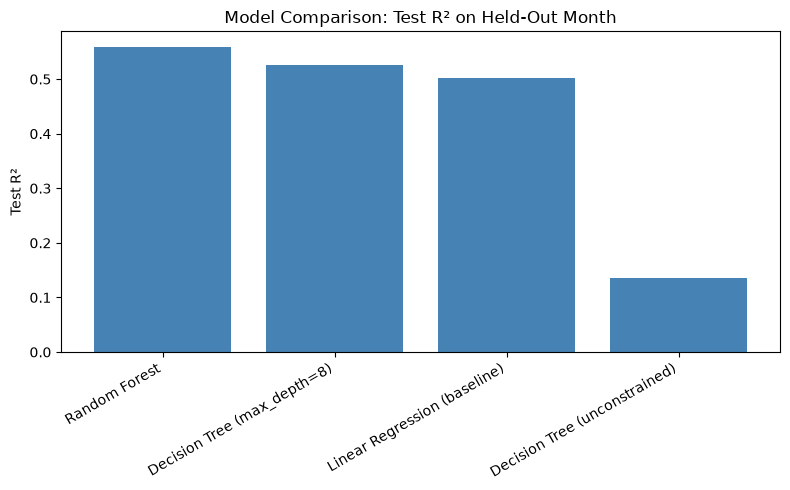

In [10]:
# Visualize test R² across all models for a quick at-a-glance comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["Test_R2"], color="steelblue")
plt.ylabel("Test R²")
plt.title("Model Comparison: Test R² on Held-Out Month")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Feature importance shows which inputs each tree-based model relies on most
importance_df = pd.DataFrame({
    "Feature": baseline_features,
    "DecisionTree_Importance": tree_model.feature_importances_,
    "RandomForest_Importance": forest_model.feature_importances_,
}).sort_values("RandomForest_Importance", ascending=False)

importance_df

,Feature,DecisionTree_Importance,RandomForest_Importance
2,BathroomsTotalInteger,0.534429,0.453934
0,LivingArea,0.277274,0.274872
4,YearBuilt,0.129597,0.141629
3,LotSizeSquareFeet,0.024926,0.058311
5,DaysOnMarket,0.017803,0.045893
1,BedroomsTotal,0.015969,0.025361


In [12]:
# The gap between train R² and test R² is a direct measure of overfitting per model
comparison_df["Overfit_Gap"] = comparison_df["Train_R2"] - comparison_df["Test_R2"]
comparison_df[["Model", "Train_R2", "Test_R2", "Overfit_Gap"]]

,Model,Train_R2,Test_R2,Overfit_Gap
0,Random Forest,0.653192,0.559599,0.093593
1,Decision Tree (max_depth=8),0.551767,0.525051,0.026716
2,Linear Regression (baseline),0.499527,0.501939,-0.002412
3,Decision Tree (unconstrained),0.999846,0.135887,0.863958


In [13]:
# Import libraries for feature engineering, the school-district spatial join, and re-training models
import os
import glob
import requests
import geopandas as gpd
from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler

In [14]:
# Reload raw monthly files and repeat Week 3's filtering/feature selection, adding Latitude/Longitude for the spatial join
files = sorted(glob.glob("data/CRMLSSold*.csv"))
raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

raw = raw[
    (raw["PropertyType"] == "Residential") &
    (raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

week6_features = [
    "CloseDate", "ClosePrice", "LivingArea", "BedroomsTotal",
    "BathroomsTotalInteger", "LotSizeSquareFeet", "City", "CountyOrParish",
    "YearBuilt", "DaysOnMarket", "Latitude", "Longitude",
]
df6 = raw[week6_features].copy()
df6["CloseDate"] = pd.to_datetime(df6["CloseDate"], errors="coerce")
df6["CloseMonth"] = df6["CloseDate"].dt.to_period("M").astype(str)

print(df6.shape)

(314368, 13)


In [15]:
# Same missing-value handling and outlier clipping as Week 3, now also requiring valid coordinates
df6 = df6.dropna(subset=["ClosePrice", "CloseDate", "Latitude", "Longitude"])

num_cols6 = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt", "DaysOnMarket"]
cat_cols6 = ["City", "CountyOrParish"]

for col in num_cols6:
    df6[col] = df6[col].fillna(df6[col].median())
for col in cat_cols6:
    df6[col] = df6[col].fillna("Unknown")

df6 = df6[
    (df6["ClosePrice"] > 0) & (df6["LivingArea"] > 0) &
    (df6["BedroomsTotal"] > 0) & (df6["BathroomsTotalInteger"] > 0) &
    (df6["LotSizeSquareFeet"] > 0)
].copy()

def iqr_clip(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return series.clip(q1 - k * iqr, q3 + k * iqr)

for col in ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]:
    df6[col] = iqr_clip(df6[col])

print(df6.shape)

(302704, 13)


In [16]:
# New engineered features: bedroom-to-bathroom ratio, and property age in years at time of sale
df6["BedBathRatio"] = df6["BedroomsTotal"] / df6["BathroomsTotalInteger"]
df6["PropertyAge"] = df6["CloseDate"].dt.year - df6["YearBuilt"]

df6[["BedroomsTotal", "BathroomsTotalInteger", "BedBathRatio", "YearBuilt", "CloseDate", "PropertyAge"]].head()

,BedroomsTotal,BathroomsTotalInteger,BedBathRatio,YearBuilt,CloseDate,PropertyAge
29,5.0,3.0,1.666667,1955.0,2024-01-29,69.0
30,4.0,4.0,1.000000,2019.0,2024-01-02,5.0
39,3.0,3.0,1.000000,1965.0,2024-01-16,59.0
43,5.0,4.0,1.250000,1994.0,2024-01-24,30.0
45,4.0,3.0,1.333333,1995.0,2024-01-31,29.0


In [17]:
# Download the CA School District Areas 2024-25 boundaries once and cache locally so re-runs are fast
os.makedirs("data/geo", exist_ok=True)
districts_path = "data/geo/ca_school_districts_2024_25.geojson"

if not os.path.exists(districts_path):
    url = "https://gis.data.ca.gov/api/download/v1/items/b0e3b936426a47ce9d9a2e77e2bb86cc/geojson?layers=0"
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    with open(districts_path, "wb") as f:
        f.write(resp.content)

districts = gpd.read_file(districts_path)
print(districts.shape)
print(districts.columns.tolist())
districts.head()

(937, 54)
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'CongressUS', 'SenateCA', 'AssemblyCA', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'Shape__Area', 'Shape__Length', 'geometry']


,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,Shape__Area,Shape__Length,geometry
0,1,2024-25,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1356,12.6,3958,36.7,11.248939,4.755489e+07,56522.982683,"MULTIPOLYGON (((-122.22678 37.72651, -122.2267..."
1,2,2024-25,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,357,9.7,1184,32.1,1.789984,7.096327e+06,12696.382797,"POLYGON ((-122.28671 37.89852, -122.28673 37.8..."
2,3,2024-25,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1111,12.1,2686,29.3,10.434329,4.364648e+07,43695.341538,"POLYGON ((-122.25606 37.89834, -122.25607 37.8..."
3,4,2024-25,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,0,0.0,1113,11.6,3728,39.0,66.885571,2.838285e+08,142492.767565,"MULTIPOLYGON (((-122.01375 37.64265, -122.0114..."
4,5,2024-25,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,81,13.7,412,69.8,1.273929,5.363392e+06,13741.272894,"POLYGON ((-122.29663 37.8311, -122.29778 37.83..."


In [18]:
# Convert each property's lat/long into a point and spatially join it to the district polygon it falls inside
DISTRICT_NAME_COL = "DistrictName"  # <-- set this to the actual column name from the printout above

geometry = [Point(xy) for xy in zip(df6["Longitude"], df6["Latitude"])]
properties_gdf = gpd.GeoDataFrame(df6.copy(), geometry=geometry, crs="EPSG:4326")
districts = districts.to_crs("EPSG:4326")

joined = gpd.sjoin(properties_gdf, districts[[DISTRICT_NAME_COL, "geometry"]], how="left", predicate="within")
joined = joined[~joined.index.duplicated(keep="first")]

print("Matched:", joined[DISTRICT_NAME_COL].notna().sum(), "of", len(joined))

Matched: 302591 of 302704


In [19]:
# Some points can miss a "within" match due to coastline/edge precision - snap those to the nearest district instead
unmatched_mask = joined[DISTRICT_NAME_COL].isna()
print("Unmatched:", unmatched_mask.sum())

if unmatched_mask.any():
    unmatched_idx = unmatched_mask[unmatched_mask].index
    unmatched = properties_gdf.loc[unmatched_idx]
    nearest = gpd.sjoin_nearest(unmatched, districts[[DISTRICT_NAME_COL, "geometry"]])
    nearest = nearest[~nearest.index.duplicated(keep="first")]
    joined.loc[unmatched_idx, DISTRICT_NAME_COL] = nearest[DISTRICT_NAME_COL].values

df6["SchoolDistrict"] = joined[DISTRICT_NAME_COL].fillna("Unknown").values
print(df6["SchoolDistrict"].nunique(), "unique districts matched")

Unmatched: 113
649 unique districts matched


/Users/amelia/Projects/IDXExchange_DataScience/venv/lib/python3.14/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [20]:
# Build a simple time-based split: most recent month held out as test, everything before it as train
months6 = sorted(df6["CloseMonth"].unique())
test_month6 = months6[-1]

train_raw6 = df6[df6["CloseMonth"] != test_month6].copy()
test_raw6 = df6[df6["CloseMonth"] == test_month6].copy()

print("Test month:", test_month6)
print("Train:", train_raw6.shape, "Test:", test_raw6.shape)

Test month: 2026-05
Train: (290356, 16) Test: (12348, 16)


In [21]:
# Reusable encoder: frequency-encode high-cardinality columns (City, SchoolDistrict), one-hot the rest, fit on train only
def encode_features(train_df, test_df, numeric_cols, high_card_cols, low_card_cols):
    train_df, test_df = train_df.copy(), test_df.copy()

    for col in high_card_cols:
        freq = train_df[col].value_counts(normalize=True)
        train_df[col + "_freq"] = train_df[col].map(freq).fillna(0)
        test_df[col + "_freq"] = test_df[col].map(freq).fillna(0)

    train_dum = pd.get_dummies(train_df[low_card_cols], drop_first=True)
    test_dum = pd.get_dummies(test_df[low_card_cols], drop_first=True)
    test_dum = test_dum.reindex(columns=train_dum.columns, fill_value=False)

    freq_cols = [c + "_freq" for c in high_card_cols]
    X_train_out = pd.concat([train_df[numeric_cols + freq_cols].reset_index(drop=True), train_dum.reset_index(drop=True)], axis=1)
    X_test_out = pd.concat([test_df[numeric_cols + freq_cols].reset_index(drop=True), test_dum.reset_index(drop=True)], axis=1)
    return X_train_out, X_test_out


def scale_numeric(X_train, X_test, numeric_cols):
    X_train, X_test = X_train.copy(), X_test.copy()
    scaler = StandardScaler()
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
    return X_train, X_test

In [22]:
# Old feature set = what Week 5 used above. New feature set = old + BedBathRatio, PropertyAge, and the school district layer
old_numeric = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet", "YearBuilt", "DaysOnMarket"]
new_numeric = old_numeric + ["BedBathRatio", "PropertyAge"]

y_train6, y_test6 = train_raw6["ClosePrice"], test_raw6["ClosePrice"]

X_train_old, X_test_old = encode_features(train_raw6, test_raw6, old_numeric, high_card_cols=["City"], low_card_cols=["CountyOrParish"])
X_train_old, X_test_old = scale_numeric(X_train_old, X_test_old, old_numeric)

X_train_new, X_test_new = encode_features(train_raw6, test_raw6, new_numeric, high_card_cols=["City", "SchoolDistrict"], low_card_cols=["CountyOrParish"])
X_train_new, X_test_new = scale_numeric(X_train_new, X_test_new, new_numeric)

print("Old feature set:", X_train_old.shape)
print("New feature set:", X_train_new.shape)

Old feature set: (290356, 69)
New feature set: (290356, 72)


In [23]:
# Train the same three model types on both the old and new feature sets so we can compare directly
# (named evaluate_model_v2 to avoid overwriting the Week 5 evaluate_model above, which has a different signature)
def evaluate_model_v2(model, X_train, y_train, X_test, y_test, model_name, feature_set_name):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        "Feature_Set": feature_set_name,
        "Model": model_name,
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "MAE": mean_absolute_error(y_test, test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    }

feature_sets = {
    "Old (Week 5)": (X_train_old, X_test_old),
    "New (Week 6)": (X_train_new, X_test_new),
}

results6 = []
for fs_name, (Xtr, Xte) in feature_sets.items():
    results6.append(evaluate_model_v2(LinearRegression(), Xtr, y_train6, Xte, y_test6, "Linear Regression", fs_name))
    results6.append(evaluate_model_v2(DecisionTreeRegressor(max_depth=8, random_state=42), Xtr, y_train6, Xte, y_test6, "Decision Tree (depth=8)", fs_name))
    results6.append(evaluate_model_v2(RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), Xtr, y_train6, Xte, y_test6, "Random Forest", fs_name))

comparison_df6 = pd.DataFrame(results6)
comparison_df6

,Feature_Set,Model,Train_R2,Test_R2,MAE,RMSE
0,Old (Week 5),Linear Regression,0.662436,0.662883,338681.545846,489503.535053
1,Old (Week 5),Decision Tree (depth=8),0.649810,0.635382,339881.770119,509078.071439
2,Old (Week 5),Random Forest,0.753635,0.723026,284373.845660,443695.755100
3,New (Week 6),Linear Regression,0.663621,0.664426,339010.616078,488382.425910
4,New (Week 6),Decision Tree (depth=8),0.650964,0.636388,339517.766219,508375.777370
5,New (Week 6),Random Forest,0.763478,0.731750,277515.968290,436652.057499


In [24]:
# Pivot so each model's old-feature-set and new-feature-set test R² sit side by side, with the improvement highlighted
pivot6 = comparison_df6.pivot(index="Model", columns="Feature_Set", values="Test_R2")
pivot6["Improvement"] = pivot6["New (Week 6)"] - pivot6["Old (Week 5)"]
pivot6 = pivot6.sort_values("Improvement", ascending=False)
pivot6

Feature_Set,New (Week 6),Old (Week 5),Improvement
Model,,,
Random Forest,0.731750,0.723026,0.008724
Linear Regression,0.664426,0.662883,0.001542
Decision Tree (depth=8),0.636388,0.635382,0.001005


In [25]:
# Refit Random Forest on the new feature set alone and check whether the new engineered features rank highly
forest_new = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
forest_new.fit(X_train_new, y_train6)

importance_df6 = pd.DataFrame({
    "Feature": X_train_new.columns,
    "Importance": forest_new.feature_importances_,
}).sort_values("Importance", ascending=False)

importance_df6.head(15)

,Feature,Importance
2,BathroomsTotalInteger,0.361719
0,LivingArea,0.198739
56,CountyOrParish_Santa Clara,0.068571
8,City_freq,0.063057
46,CountyOrParish_Riverside,0.052761
49,CountyOrParish_San Bernardino,0.049786
7,PropertyAge,0.040789
54,CountyOrParish_San Mateo,0.028875
9,SchoolDistrict_freq,0.028810
40,CountyOrParish_Orange,0.026917


In [26]:
# Save the old-vs-new feature set comparison table as the Week 6 deliverable
comparison_df6.to_csv("output/week6_model_comparison.csv", index=False)
pivot6.to_csv("output/week6_old_vs_new_pivot.csv")
print("Saved output/week6_model_comparison.csv and output/week6_old_vs_new_pivot.csv")

Saved output/week6_model_comparison.csv and output/week6_old_vs_new_pivot.csv


In [28]:
# ---------------------------------------------------------------
# Full-feature comparison: same LR / DT / RF models, now trained on
# the SAME 72-column feature set as XGBoost/LightGBM (output/train.csv,
# output/test.csv — includes City/CountyOrParish location encoding),
# so MdAPE is directly comparable across every model in this project.
# ---------------------------------------------------------------
linear_model_full = LinearRegression()
linear_model_full.fit(X_train_full, y_train)

tree_model_full = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_model_full.fit(X_train_full, y_train)

forest_model_full = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
forest_model_full.fit(X_train_full, y_train)

full_results = []
full_results.append(evaluate_model(linear_model_full, X_train_full, y_train, X_test_full, y_test, "Linear Regression (full features)"))
full_results.append(evaluate_model(tree_model_full, X_train_full, y_train, X_test_full, y_test, "Decision Tree (full features)"))
full_results.append(evaluate_model(forest_model_full, X_train_full, y_train, X_test_full, y_test, "Random Forest (full features)"))

full_comparison_df = pd.DataFrame(full_results).sort_values("Test_R2", ascending=False).reset_index(drop=True)
full_comparison_df

Linear Regression (full features)
---------------------------------
Train R²: 0.6572   Test R²: 0.6591
Test MAE: $344,441   Test RMSE: $498,184
Test MAPE: 34.05%   Test MdAPE: 24.75%

Decision Tree (full features)
-----------------------------
Train R²: 0.6435   Test R²: 0.6330
Test MAE: $342,442   Test RMSE: $516,859
Test MAPE: 35.82%   Test MdAPE: 21.28%

Random Forest (full features)
-----------------------------
Train R²: 0.7507   Test R²: 0.7200
Test MAE: $288,414   Test RMSE: $451,499
Test MAPE: 28.87%   Test MdAPE: 16.99%



,Model,Train_R2,Test_R2,MAE,RMSE,MAPE,MdAPE
0,Random Forest (full features),0.750698,0.719982,288413.857532,451499.429228,28.870829,16.986346
1,Linear Regression (full features),0.657222,0.659080,344440.908780,498184.272328,34.050761,24.748287
2,Decision Tree (full features),0.643482,0.633042,342442.226609,516858.912459,35.816058,21.281381


In [29]:
full_comparison_df.to_csv("output/full_feature_model_comparison.csv", index=False)
print("Saved output/full_feature_model_comparison.csv")

Saved output/full_feature_model_comparison.csv
